Q1. (Loading the Dataset)
Download the Emotions Dataset for NLP from Kaggle (or use the provided
train.txt).
Load the dataset using pandas with separator ; and column names ['text',
'emotions'].
Display the first 10 rows and the shape of the dataset.
Check for missing values using isnull().sum().

In [ ]:
import pandas as pd
# Load the dataset (assuming train.txt is in your working directory)
df = pd.read_csv("train.txt", sep=";", names=["text", "emotions"])
# Display the first 10 rows
print("First 10 rows:")
print(df.head(10))
# Display the shape of the dataset
print("\nShape of dataset:", df.shape)
# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

First 10 rows:
                                                text  emotions
0                            i didnt feel humiliated   sadness
1  i can go from feeling so hopeless to so damned...   sadness
2   im grabbing a minute to post i feel greedy wrong     anger
3  i am ever feeling nostalgic about the fireplac...      love
4                               i am feeling grouchy     anger
5  ive been feeling a little burdened lately wasn...   sadness
6  ive been taking or milligrams or times recomme...  surprise
7  i feel as confused about life as a teenager or...      fear
8  i have been with petronas for years i feel tha...       joy
9                                i feel romantic too      love

Shape of dataset: (16000, 2)

Missing values:
text        0
emotions    0
dtype: int64


Q2. (Exploring Target Labels)
Find and print all unique emotion labels present in the dataset.
Use LabelEncoder to convert the emotion labels into numeric values.
Create a dictionary mapping original emotion names to their encoded numbers
and display it.
Add the encoded labels as a new column in the DataFrame.

In [ ]:
from sklearn.preprocessing import LabelEncoder
#Find all unique emotion labels
unique_emotions = df["emotions"].unique()
print("Unique emotion labels:", unique_emotions)
#Encode labels using LabelEncoder
encoder = LabelEncoder()
df["encoded_labels"] = encoder.fit_transform(df["emotions"])
#Create dictionary mapping original labels to encoded numbers
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("\nLabel Mapping (emotion → number):")
print(label_mapping)
#Display DataFrame with new column
print("\nFirst 10 rows with encoded labels:")
print(df.head(10))

Unique emotion labels: <ArrowStringArray>
['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']
Length: 6, dtype: str

Label Mapping (emotion → number):
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}

First 10 rows with encoded labels:
                                                text  emotions  encoded_labels
0                            i didnt feel humiliated   sadness               4
1  i can go from feeling so hopeless to so damned...   sadness               4
2   im grabbing a minute to post i feel greedy wrong     anger               0
3  i am ever feeling nostalgic about the fireplac...      love               3
4                               i am feeling grouchy     anger               0
5  ive been feeling a little burdened lately wasn...   sadness               4
6  ive been taking or milligrams or times recomme...  surprise               5
7  i feel as confused about life as a teena

Q3. (Lowercasing)
Convert the entire text column to lowercase.
Show 5 sample texts before and after lowercasing.
Write a short note on why lowercasing is important in NLP.

In [ ]:
#5 sample texts before lowercasing
print("Before lowercasing:")
print(df["text"].sample(5))

# Converts text column to lowercase
df["text"] = df["text"].str.lower()

#5 sample texts after lowercasing
print("\nAfter lowercasing:")
print(df["text"].sample(5))


Before lowercasing:
1530                  i can wear anything and not feel bad
14032    i do not agree with hirsi ali on policy matter...
3835     i feel bad about being depressed because there...
12796    being reunited with my family after not having...
13157    i was slicing a knife through a creamy cheesec...
Name: text, dtype: str

After lowercasing:
6185     i feel blessed to have found such a wonderful ...
15385    i also got a chance to watch my cousin dance i...
6072     i feel that because of our own love of reading...
1617     i feel like reading anansi boys again its gorg...
239      i tried to fill it by befriending people that ...
Name: text, dtype: str


Q4. (Removing Punctuation)
Write a function to remove all punctuation marks from the text.
Apply the function to the text column.
Display 5 examples before and after punctuation removal.

In [ ]:
import string
# Function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))
# 5 examples before punctuation removal
print("Before punctuation removal:")
print(df["text"].sample(5))
# Apply function to text column
df["text"] = df["text"].apply(remove_punctuation)
# 5 examples after punctuation removal
print("\nAfter punctuation removal:")
print(df["text"].sample(5))

Before punctuation removal:
4919     i feel stumped something comes out of my pen a...
3611     i got the feeling watching it that only from s...
15519    i can also song write without feeling all bash...
7142     i feel so blessed and beyond thankful for the ...
13976    i have myself a great tutor to teach me on mag...
Name: text, dtype: str

After punctuation removal:
5913     i am currently feeling like you know that kind...
12446    i have a feeling she will sleep through the ni...
15087    im not sure i can go back to aussie festivals ...
127      i am feeling horny so i ask her that lets go home
526      i couldnt help but feel totally distraught and...
Name: text, dtype: str


Q5. (Removing Numbers)
Write a function that removes all digits from the text.
Apply it to the cleaned text column.
Show before and after examples.

In [ ]:
import re

# Function to remove digits
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

#  5 examples before number removal
print("Before number removal:")
print(df["text"].sample(5))

# Apply function to text column
df["text"] = df["text"].apply(remove_numbers)

#  5 examples after number removal
print("\nAfter number removal:")
print(df["text"].sample(5))


Before number removal:
1896     i feel it breeds loneliness and discontent and...
2185           im feeling envious of my pregant co workers
14833              i was feeling good until i saw the flop
6863     i also have learned that feelings cant hurt me...
15152    i just have to allow myself to loosen up a bit...
Name: text, dtype: str

After number removal:
4543     i am standing in my oversized tee shirt baggy ...
14538    i feel like i am unhappy missing too much from...
4544     i feel indecisive about baker although my room...
12155    ive not used elvive for years and i admit to f...
180      i am no fan of the current president i am a co...
Name: text, dtype: str


Q6. (Removing Emojis & Special Characters)
Write a function that keeps only ASCII characters (to remove emojis and special
symbols).
Apply the function to the text column.
Display a few examples of the cleaned text.

In [ ]:
# Function to keep only ASCII characters (removes emojis & special symbols)
def remove_non_ascii(text):
    return text.encode("ascii", "ignore").decode("ascii")

#  5 examples before cleaning
print("Before removing emojis & special characters:")
print(df["text"].sample(5))

# Apply function to text column
df["text"] = df["text"].apply(remove_non_ascii)

#  5 examples after cleaning
print("\nAfter removing emojis & special characters:")
print(df["text"].sample(5))


Before removing emojis & special characters:
5992                       i did in fact feel very strange
10317                 i was hoping by then i would feel ok
156      im certainly not going to sit and tell you wha...
2734     i had expected it to be rather sickly and the ...
12492    im feeling plunge us into a world of melanchol...
Name: text, dtype: str

After removing emojis & special characters:
4522     i am feeling quite pleased with myself as this...
6237         i feel sooo bitchy that i made out with devin
404                 i was feeling like a pretty crappy mom
4245                            i feel completely agitated
15113    i feel the wrapping of the gift is almost as i...
Name: text, dtype: str


Q7. (Removing Stopwords)
Download the necessary NLTK resources (punkt and stopwords).
Load English stopwords.
Write a function to remove stopwords from the text.
Apply the function and show 5 cleaned text samples.

In [ ]:
import nltk
from nltk.corpus import stopwords
# Download necessary NLTK resources (only once)
nltk.download("punkt")
nltk.download("stopwords")
# Load dataset again (if not already loaded)
df = pd.read_csv("train.txt", sep=";", names=["text", "emotions"])
# Load English stopwords
stop_words = set(stopwords.words("english"))
# Function to remove stopwords
def remove_stopwords(text):
    words = text.split()  # split text into words
    filtered_words = [w for w in words if w.lower() not in stop_words]
    return " ".join(filtered_words)
# 5 examples before stopword removal
print("Before stopword removal:")
print(df["text"].sample(5))
# Apply function to text column
df["text"] = df["text"].apply(remove_stopwords)
# 5 examples after stopword removal
print("\nAfter stopword removal:")
print(df["text"].sample(5))

[nltk_data] Downloading package punkt to C:\Users\HP-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\HP-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Before stopword removal:
2927     i feel angry because i have led myself to lead...
14769    i was feeling rather smug about being a black ...
4698     i started to sprint even when i consciously th...
7643     i leave feeling challenged and eager to study ...
11485    i feel pretty honored to be around some really...
Name: text, dtype: str

After stopword removal:
15794                feel distracted well weight managment
9406     think thats exactly ill love year school leavi...
951                                         id feel better
9457     read premonition rare feeling caught dewi lest...
11268            started feeling bit alarmed afraid reason
Name: text, dtype: str


Q8. (Complete Text Cleaning Pipeline)
Combine all the cleaning steps from Q3 to Q7 into a single cleaning function.
Apply the complete pipeline on the original text column.
Create a new column called cleaned_text.
Display the original text and cleaned text side by side for 10 samples.

In [30]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")


[nltk_data] Downloading package punkt to C:\Users\HP-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\HP-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\HP-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
# Download NLTK resources (only once)
nltk.download("punkt")
nltk.download("stopwords")
# Load English stopwords
stop_words = set(stopwords.words("english"))
# Complete cleaning function
def clean_text(text):
    # 1. Lowercasing
    text = text.lower()
    # 2. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 4. Remove emojis & special characters (keep only ASCII)
    text = text.encode("ascii", "ignore").decode("ascii")
    # 5. Remove stopwords
    words = text.split()  # split text into words
    filtered_words = [w for w in words if w not in stop_words]
    text = " ".join(filtered_words)
    return text
# Apply pipeline to original text column
df["cleaned_text"] = df["text"].apply(clean_text)
# Display original vs cleaned text for 10 samples
print(df[["text", "cleaned_text"]].head(10))

[nltk_data] Downloading package punkt to C:\Users\HP-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\HP-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   
5  ive been feeling a little burdened lately wasn...   
6  ive been taking or milligrams or times recomme...   
7  i feel as confused about life as a teenager or...   
8  i have been with petronas for years i feel tha...   
9                                i feel romantic too   

                                        cleaned_text  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  
5      ive feeling little burdened lately wasnt sure 

Q9. (Text Length Analysis)
After cleaning:
Calculate the number of words in each cleaned text.
Plot a histogram of text lengths.
Print the average, minimum, and maximum text length.
Write observations about the cleaned data.

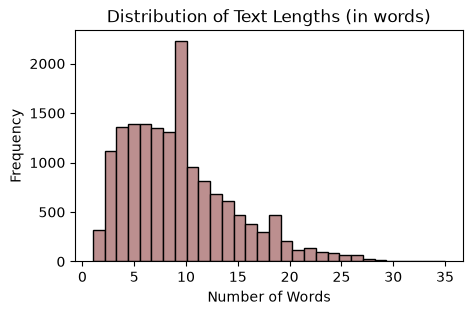

Average text length: 9.3530625
Minimum text length: 1
Maximum text length: 35


In [42]:
import matplotlib.pyplot as plt
#Calculate number of words in each cleaned text
df["text_length"] = df["cleaned_text"].apply(lambda x: len(x.split()))
#Plot histogram of text lengths
plt.figure(figsize=(5, 3))
plt.hist(df["text_length"], bins=30, color="rosybrown", edgecolor="black")
plt.title("Distribution of Text Lengths (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()
#Print average, minimum, and maximum text length
avg_length = df["text_length"].mean()
min_length = df["text_length"].min()
max_length = df["text_length"].max()
print("Average text length:", avg_length)
print("Minimum text length:", min_length)
print("Maximum text length:", max_length)

Q10. (Mini Project – Full Preprocessing Pipeline)
Using the Emotions Dataset:
1. Load the data
2. Encode the emotion labels
3. Perform complete text cleaning (lowercase → punctuation → numbers →
emojis → stopwords)
4. Save the cleaned dataset as cleaned_emotions.csv
5. Show value counts of each emotion

In [ ]:
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
# Step 1: Load the data
df = pd.read_csv("train.txt", sep=";", names=["text", "emotions"])
# Step 2: Encode the emotion labels
encoder = LabelEncoder()
df["encoded_labels"] = encoder.fit_transform(df["emotions"])
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Label Mapping:", label_mapping)
# Step 3: Complete text cleaning pipeline
nltk.download("punkt")
nltk.download("punkt_tab")   # Fix for tokenizer tables
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove emojis & special characters
    text = text.encode("ascii", "ignore").decode("ascii")
    # Remove stopwords
    words =text.split()  
    filtered_words = [w for w in words if w not in stop_words]
    return " ".join(filtered_words)
df["cleaned_text"] = df["text"].apply(clean_text)
# Step 4: Save the cleaned dataset
df.to_csv("cleaned_emotions.csv", index=False)
# Step 5: Show value counts of each emotion
print("\nEmotion counts:")
print(df["emotions"].value_counts())

Label Mapping: {'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


[nltk_data] Downloading package punkt to C:\Users\HP-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\HP-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\HP-
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Emotion counts:
emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64
